In [1]:
from typing import List
import re

import numpy as np
from matplotlib import pyplot as plt
import matplotlib

# include the path to the parent directory

import sys
sys.path.append('../../')

from mfgpflow.data_loader import StellarMassFunctions

# set a random number seed to reproducibility
np.random.seed(0)

# SB28 CAMELS simulation multi-fidelity emulator


In [2]:
import pandas as pd

In [3]:
basedir = "../../data/SB28/ming-feng/"
#  The SMFs are obtained from the stellar mass of the galaxy catalog, 
# with each binned into 13 bins in the range [108.9, 1011.4] M⊙ which Leja et al. (2020) aims at.
log10M = np.array([
    8.15,  8.45,  8.75,  9.05,  9.35,  9.65, 9.95, 10.25, 10.55, 10.85, 11.15, 11.45, 11.75,
], dtype=np.float32)
snap_number = 73

# CosmoAstroSeed_IllustrisTNG_L25n128_SB28_MF.txt SB28_low_smf_13bins_73.npy
# CosmoAstroSeed_IllustrisTNG_L25n512_SB28_MF.txt SB28_low_smf_13bins_90.npy
# SB28_high_smf_13bins_73.npy                     SB28_smf_13bins_73.npy
# SB28_high_smf_13bins_90.npy                     SB28_smf_13bins_90.npy

#### Low-fidelity Data Preparation ####
# parameters
filename = "CosmoAstroSeed_IllustrisTNG_L25n256_SB28.txt"
df = pd.read_table(
    basedir + filename,
    sep=r"\s+",              # equivalent to delim_whitespace=True but future-proof
    header=0,                # first row is header
    index_col=0              # optional: set "Name" as index
)
# SMF data
phi = np.load(basedir + "SB28_smf_13bins_{}.npy".format(snap_number), allow_pickle=True)

#### High-fidelity Data Preparation ####
# parameters
filename_hf = "CosmoAstroSeed_IllustrisTNG_L25n512_SB28_MF.txt"
df_hf = pd.read_table(
    basedir + filename_hf,
    sep=r"\s+",              # equivalent to delim_whitespace=True but future-proof
    header=0,                # first row is header
    index_col=0              # optional: set "Name" as index
)
# SMF data HF
phi_hf = np.load(basedir + "SB28_high_smf_13bins_{}.npy".format(snap_number), allow_pickle=True)

#### Extremely low-fidelity Data Preparation ####
# parameters
filename_lf = "CosmoAstroSeed_IllustrisTNG_L25n128_SB28_MF.txt"
df_lf = pd.read_table(
    basedir + filename_lf,
    sep=r"\s+",              # equivalent to delim_whitespace=True but future-proof
    header=0,                # first row is header
    index_col=0              # optional: set "Name" as index
)
# SMF data LF
phi_lf = np.load(basedir + "SB28_low_smf_13bins_{}.npy".format(snap_number), allow_pickle=True)
# print(df_lf.shape)
# print(df_lf.head())

print(df.shape)
print(df.head())
print(df_hf.shape)
df_hf.head()

(2048, 29)
          Omega0    sigma8  WindEnergyIn1e51erg  RadioFeedbackFactor  \
#Name                                                                  
SB28_0  0.352541  0.694742              3.85743             1.519210   
SB28_1  0.172430  0.830154              1.03554             0.797734   
SB28_2  0.234683  0.705844              9.61416             3.380650   
SB28_3  0.440288  0.969259              2.14363             0.488165   
SB28_4  0.457152  0.786733              1.38466             0.325727   

        VariableWindVelFactor  RadioFeedbackReiorientationFactor  OmegaBaryon  \
#Name                                                                           
SB28_0                9.09267                            14.2845     0.049404   
SB28_1                6.95693                            38.2374     0.031199   
SB28_2                3.77681                            24.6592     0.042995   
SB28_3               11.49660                            10.9550     0.062295  

,Omega0,sigma8,WindEnergyIn1e51erg,RadioFeedbackFactor,VariableWindVelFactor,RadioFeedbackReiorientationFactor,OmegaBaryon,HubbleParam,n_s,MaxSfrTimescale,...,WindEnergyReductionExponent,WindDumpFactor,SeedBlackHoleMass,BlackHoleAccretionFactor,BlackHoleEddingtonFactor,BlackHoleFeedbackFactor,BlackHoleRadiativeEfficiency,QuasarThreshold,QuasarThresholdPower,seed
#Name,,,,,,,,,,,,,,,,,,,,,
SB28_0,0.16496,0.96909,1.3445,3.57840,5.5830,38.888,0.043027,0.71877,1.15060,3.5877,...,1.7170,0.27688,0.000050,3.67120,8.72280,0.166960,0.111250,0.006348,2.06490,100000
SB28_1,0.47544,0.61113,4.3166,0.42142,10.3570,18.216,0.063581,0.59376,0.81216,1.7244,...,2.0739,0.80598,0.000093,0.98946,0.52115,0.029685,0.483060,0.000085,1.00550,100001
SB28_2,0.29521,0.74784,1.8710,0.57375,5.2247,12.932,0.037454,0.50521,0.90049,2.4069,...,2.9175,0.55940,0.000175,1.23470,0.11679,0.087780,0.076229,0.016122,3.66810,100002
SB28_3,0.35813,0.88393,12.9730,1.10490,11.0670,27.534,0.056898,0.78019,1.06200,1.2608,...,1.3106,0.73264,0.000028,0.31182,2.16770,0.247020,0.392550,0.001207,0.73024,100003
SB28_4,0.13889,0.66285,9.7200,0.72967,7.9372,33.131,0.029955,0.83604,0.93135,2.1920,...,1.9076,0.98005,0.000038,0.38432,5.53480,0.054527,0.585050,0.002399,3.12420,100004


In [4]:
df

,Omega0,sigma8,WindEnergyIn1e51erg,RadioFeedbackFactor,VariableWindVelFactor,RadioFeedbackReiorientationFactor,OmegaBaryon,HubbleParam,n_s,MaxSfrTimescale,...,WindEnergyReductionExponent,WindDumpFactor,SeedBlackHoleMass,BlackHoleAccretionFactor,BlackHoleEddingtonFactor,BlackHoleFeedbackFactor,BlackHoleRadiativeEfficiency,QuasarThreshold,QuasarThresholdPower,seed
#Name,,,,,,,,,,,,,,,,,,,,,
SB28_0,0.352541,0.694742,3.85743,1.519210,9.09267,14.2845,0.049404,0.498145,0.795765,1.98816,...,1.61148,0.435971,0.000069,1.111740,2.613460,0.039463,0.225386,0.000269,0.514648,20000
SB28_1,0.172430,0.830154,1.03554,0.797734,6.95693,38.2374,0.031199,0.683693,1.142160,3.48514,...,2.08951,0.612056,0.000094,0.889955,0.302262,0.151352,0.086231,0.022802,2.620780,20001
SB28_2,0.234683,0.705844,9.61416,3.380650,3.77681,24.6592,0.042995,0.849506,0.923545,1.17740,...,1.33988,0.878906,0.000153,0.364219,8.235920,0.099772,0.648096,0.001458,3.389560,20002
SB28_3,0.440288,0.969259,2.14363,0.488165,11.49660,10.9550,0.062295,0.638970,0.964648,2.91871,...,2.86478,0.253435,0.000041,2.775960,0.950425,0.349945,0.126670,0.004242,1.494400,20003
SB28_4,0.457152,0.786733,1.38466,0.325727,13.19410,17.1439,0.044425,0.773770,0.900256,1.35439,...,2.59030,0.944457,0.000049,0.286789,1.121900,0.032352,0.460414,0.007438,2.299550,20004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SB28_2043,0.457334,0.970226,8.89733,0.607197,3.75653,39.5139,0.046041,0.513293,0.828903,1.60258,...,1.88784,0.725070,0.000054,0.327481,4.790910,0.033553,0.481742,0.001252,2.191720,22043
SB28_2044,0.440496,0.786137,5.34131,0.880840,5.04789,21.6844,0.063161,0.748997,1.143290,2.96760,...,1.66098,0.472330,0.000038,2.229260,0.222157,0.397001,0.109068,0.000416,1.012360,22044
SB28_2045,0.234475,0.938760,1.49723,1.873430,13.26680,13.5869,0.042461,0.534548,0.796116,1.30536,...,2.13803,0.698393,0.000174,0.453541,1.920250,0.087029,0.682619,0.006263,3.117210,22045


In [5]:
# parameter limits
df_info = pd.read_table(
    basedir + "Info_IllustrisTNG_L25n256_28params.txt",
    sep=r",",              # equivalent to delim_whitespace=True but future-proof
)
df_info.loc[:, ["MinVal", "MaxVal"]].to_numpy(dtype=float)



array([[ 1.0000e-01,  5.0000e-01],
       [ 6.0000e-01,  1.0000e+00],
       [ 9.0000e-01,  1.4400e+01],
       [ 2.5000e-01,  4.0000e+00],
       [ 3.7000e+00,  1.4800e+01],
       [ 1.0000e+01,  4.0000e+01],
       [ 2.9000e-02,  6.9000e-02],
       [ 4.7110e-01,  8.7110e-01],
       [ 7.6240e-01,  1.1624e+00],
       [ 1.1350e+00,  4.5400e+00],
       [ 1.0000e-01,  9.0000e-01],
       [-2.8000e+00, -1.8000e+00],
       [ 4.0000e+00,  1.2000e+01],
       [ 2.5000e-02,  4.0000e-01],
       [ 0.0000e+00,  4.0000e+03],
       [ 5.0000e-03,  5.0000e-01],
       [ 1.5000e+02,  5.5000e+02],
       [ 6.2500e-02,  1.0000e+00],
       [ 5.0000e-04,  8.0000e-03],
       [ 1.0000e+00,  3.0000e+00],
       [ 2.0000e-01,  1.0000e+00],
       [ 2.5316e-05,  2.5280e-04],
       [ 2.5000e-01,  4.0000e+00],
       [ 1.0000e-01,  1.0000e+01],
       [ 2.5000e-02,  4.0000e-01],
       [ 5.0000e-02,  8.0000e-01],
       [ 6.3300e-05,  6.3200e-02],
       [ 0.0000e+00,  4.0000e+00]])

## Noise calculation

### Poisson Counting Noise with Jeffreys Prior

For a stellar mass function (SMF) bin, let the underlying mean galaxy count be $\lambda$, and the observed count be $n$.

Assume:
$$
n \mid \lambda \sim \mathrm{Poisson}(\lambda)
$$

#### Jeffreys Prior for $\lambda$
$$
p(\lambda) \propto \lambda^{-1/2}
$$

#### Posterior Distribution
By Bayes’ rule:
$$
p(\lambda \mid n) \propto 
\underbrace{\frac{\lambda^n e^{-\lambda}}{n!}}_{\text{Poisson likelihood}}
\;\underbrace{\lambda^{-1/2}}_{\text{Jeffreys prior}}
= \lambda^{\,n-\tfrac12} e^{-\lambda}.
$$
Hence
$$
\lambda \mid n \sim \mathrm{Gamma}\!\left(\alpha=n+\tfrac12,\;\beta=1\right),
$$
where $\alpha$ is shape and $\beta$ is rate.

#### Posterior Moments
For $\lambda \sim \mathrm{Gamma}(\alpha,\beta)$:
$$
\mathbb{E}[\lambda]=\frac{\alpha}{\beta}=n+\tfrac12,
\qquad
\mathrm{Var}(\lambda)=\frac{\alpha}{\beta^2}=n+\tfrac12.
$$

#### Propagating to SMF $\phi$
Let $V=L^3$ be the box volume and $\Delta\log_{10} M$ the bin width in dex. Counts and SMF relate by
$$
n=\phi\,V\,\Delta\log_{10} M.
$$
Thus
$$
\mathrm{Var}(\phi)=\frac{\mathrm{Var}(n)}{(V\,\Delta\log_{10} M)^2}.
$$
- **Poisson model:** $\mathrm{Var}(n)=n$.
- **Jeffreys–Poisson:** $\mathrm{Var}(n)=n+\tfrac12$.

#### Why Use Jeffreys?
- For large $n$, $n+\tfrac12 \approx n$ (matches Poisson).
- For $n=0$, Poisson gives zero uncertainty, while Jeffreys yields a finite variance $0.5$, avoiding overconfidence in empty bins.

In [6]:
import numpy as np

def smf_uncertainty_batch(
    phi,                    # shape (N, B): SMF in (h^3 Mpc^-3 dex^-1)
    dlog10M,                # scalar or shape (B,): bin widths in dex
    Lbox_mpc_over_h=25.0,   # box length in (Mpc/h)
    frac_floor=0.0,         # e.g. 0.02 for a 2% numerical floor
    count_model="poisson"   # "poisson" or "jeffreys"
):
    """
    Return implied counts and per-bin uncertainties for a batch of SMFs.

    Parameters
    ----------
    phi : (N, B) array
        SMF values per simulation and mass bin [(h^3 Mpc^-3 dex^-1)].
    dlog10M : float or (B,) array
        Bin widths in dex.
    Lbox_mpc_over_h : float
        Box side length in (Mpc/h). Volume = L^3 in (Mpc/h)^3.
    frac_floor : float
        Optional additional fractional floor (e.g., catalog/binning jitter).
    count_model : {"poisson", "jeffreys"}
        - "poisson": Var(n) = n (standard). If n=0 → σ=0.
        - "jeffreys": uses Gamma(n + 0.5, 1) posterior ⇒ Var(n) ≈ n + 0.5,
          giving a nonzero σ even when n=0.

    Returns
    -------
    n_counts : (N, B) float
        Implied counts per bin (can be non-integer if phi is continuous).
    sigma_phi_poissonlike : (N, B) float
        1σ uncertainties from the chosen count model (Poisson/Jeffreys) only.
    sigma_phi_total : (N, B) float
        Total 1σ uncertainties after adding the fractional floor in quadrature.
    """
    phi = np.asarray(phi, dtype=float)              # (N, B)
    N, B = phi.shape

    if np.ndim(dlog10M) == 0:
        dlog10M = np.full(B, float(dlog10M), dtype=float)
    else:
        dlog10M = np.asarray(dlog10M, dtype=float)
        assert dlog10M.shape == (B,), "dlog10M must be scalar or shape (B,)"

    V = float(Lbox_mpc_over_h) ** 3                # (Mpc/h)^3
    dM = dlog10M.reshape(1, B)                      # (1, B) for broadcasting

    # Implied counts: n = φ * V * Δlog10M
    n_counts = phi * V * dM                         # (N, B)

    # Choose variance model for counts
    if count_model.lower() == "poisson":
        var_n = np.clip(n_counts, a_min=0.0, a_max=None)
    elif count_model.lower() == "jeffreys":
        # Gamma(n + 0.5, 1): mean = n+0.5, var = n+0.5  → nonzero at n=0
        var_n = np.clip(n_counts + 0.5, a_min=0.0, a_max=None)
    else:
        raise ValueError("count_model must be 'poisson' or 'jeffreys'")

    # Propagate to φ: Var(φ) = Var(n) / (V * Δlog10M)^2
    denom = (V * dM) ** 2
    var_phi = var_n / denom
    sigma_phi_poissonlike = np.sqrt(var_phi)

    # Optional numerical floor (fraction of |φ|)
    sigma_floor = frac_floor * np.abs(phi)

    # Total in quadrature
    sigma_phi_total = np.sqrt(sigma_phi_poissonlike**2 + sigma_floor**2)

    return n_counts, sigma_phi_poissonlike, sigma_phi_total

In [7]:
# phi has shape (N, B)
Lbox_mpc_over_h = 25.0                       # box length in Mpc/h
dlog10M = np.mean(log10M[1:] - log10M[:-1])  # bin widths in dex
frac_floor = 0.00 # e.g. 0.02 for a 2% numerical floor
count_model = "jeffreys"  # "poisson" or "jeffreys"

############ L25n256 ############
# Example: all bins 0.2 dex wide; 25 Mpc/h box; 1% numerical floor; Jeffreys small-n
n, s_poiss, s_tot = smf_uncertainty_batch(
    phi, dlog10M=dlog10M, Lbox_mpc_over_h=Lbox_mpc_over_h, frac_floor=frac_floor, count_model=count_model
)
# Alternative plotting: possion
_, s_poiss_alt, s_tot_alt = smf_uncertainty_batch(
    phi, dlog10M=dlog10M, Lbox_mpc_over_h=Lbox_mpc_over_h, frac_floor=frac_floor, count_model="poisson"
)

############ L25n512 ############
# Example: all bins 0.2 dex wide; 25 Mpc/h box; 1% numerical floor; Jeffreys small-n
n_hf, s_poiss_hf, s_tot_hf = smf_uncertainty_batch(
    phi_hf, dlog10M=dlog10M, Lbox_mpc_over_h=Lbox_mpc_over_h, frac_floor=frac_floor, count_model=count_model
)
# Alternative plotting: possion
_, s_poiss_hf_alt, s_tot_hf_alt = smf_uncertainty_batch(
    phi_hf, dlog10M=dlog10M, Lbox_mpc_over_h=Lbox_mpc_over_h, frac_floor=frac_floor, count_model="poisson"
)


# If your bins have varying widths:
# dlog10M = np.array([0.2, 0.2, 0.25, 0.25, ..., ], dtype=float)  # length B
# n, s_poiss, s_tot = smf_uncertainty_batch(phi, dlog10M, 25.0, 0.01, "poisson")

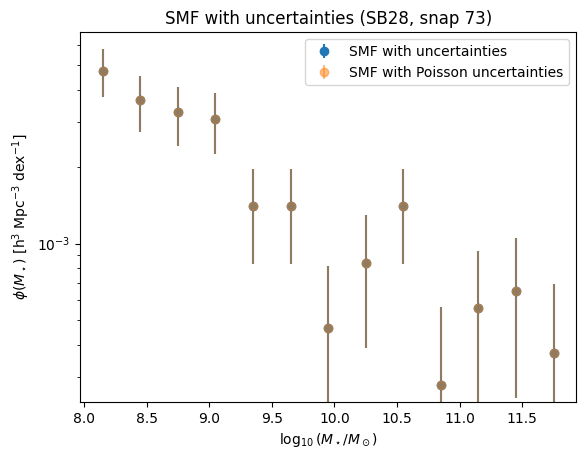

In [8]:
## Initial plotting for different uncertainties
sim_idx = 2  # e.g., index for SB28 low-fidelity data

plt.errorbar(log10M, phi[sim_idx, :], yerr=s_tot[sim_idx, :], fmt='o', label='SMF with uncertainties')
plt.errorbar(log10M, phi[sim_idx, :], yerr=s_poiss[sim_idx, :], fmt='o', label='SMF with Poisson uncertainties', alpha=0.5)

plt.xlabel(r"$\log_{10}(M_\star / M_\odot)$")
plt.ylabel(r"$\phi(M_\star)$ [h$^3$ Mpc$^{-3}$ dex$^{-1}$]")
plt.yscale('log')

plt.title("SMF with uncertainties (SB28, snap 73)")
plt.legend()

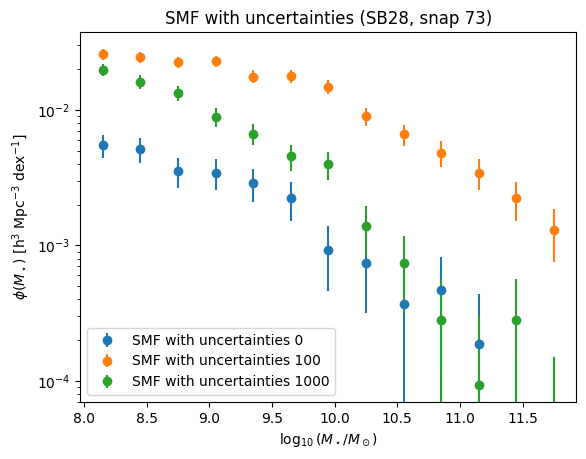

In [9]:
## Plotting multiple simulations

for sim_idx in [0, 100, 1000]:
    plt.errorbar(log10M, phi[sim_idx, :], yerr=s_tot[sim_idx, :], fmt='o', label='SMF with uncertainties {}'.format(sim_idx))

plt.xlabel(r"$\log_{10}(M_\star / M_\odot)$")
plt.ylabel(r"$\phi(M_\star)$ [h$^3$ Mpc$^{-3}$ dex$^{-1}$]")
plt.yscale('log')

plt.title("SMF with uncertainties (SB28, snap 73)")
plt.legend()

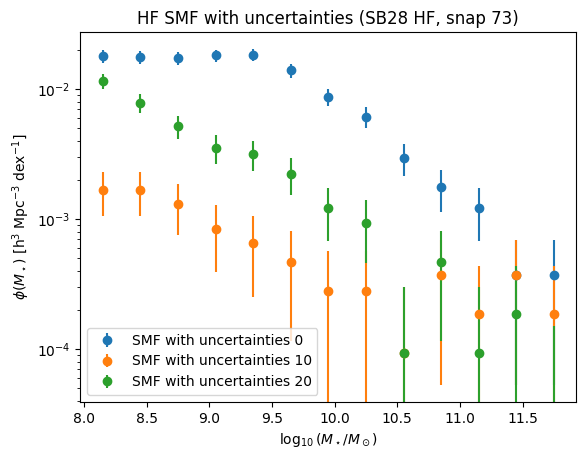

In [10]:
## HF Plotting multiple simulations

for sim_idx in [0, 10, 20]:
    plt.errorbar(log10M, phi_hf[sim_idx, :], yerr=s_tot_hf[sim_idx, :], fmt='o', label='SMF with uncertainties {}'.format(sim_idx))

plt.xlabel(r"$\log_{10}(M_\star / M_\odot)$")
plt.ylabel(r"$\phi(M_\star)$ [h$^3$ Mpc$^{-3}$ dex$^{-1}$]")
plt.yscale('log')

plt.title("HF SMF with uncertainties (SB28 HF, snap 73)")
plt.legend()

## Anscombe transformation

In [11]:
from typing import Tuple
def to_counts(phi: np.ndarray, dlog10M: np.ndarray, Lbox: float) -> np.ndarray:
    """phi→counts for stacked snapshots.
    phi: (N, B*S), dlog10M: (B,), S snapshots → we tile widths to (B*S,).
    """
    phi = np.asarray(phi, dtype=float)
    B = int(dlog10M.shape[0])
    S = phi.shape[1] // B
    d = np.tile(dlog10M, S)  # (B*S,)
    V = float(Lbox) ** 3
    return phi * (V * d)


def anscombe(n: np.ndarray) -> np.ndarray:
    return 2.0 * np.sqrt(n + 3.0 / 8.0)


def inv_anscombe_mean_var(mA: np.ndarray, vA: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    n_hat = (mA * 0.5) ** 2 - 3.0 / 8.0
    var_n = (mA * 0.5) ** 2 * vA
    return n_hat, var_n

def anscombe_sigma_from_counts_var(n: np.ndarray, var_n: np.ndarray) -> np.ndarray:
    """
    Delta-method 1σ for Anscombe A(n)=2*sqrt(n+3/8):
    Var[A] ≈ Var[n] * (dA/dn)^2 = Var[n] / (n+3/8)
    """
    denom = n + 3.0/8.0
    return np.sqrt(np.divide(var_n, denom, out=np.zeros_like(var_n, dtype=float), where=denom>0))

import numpy as np
from typing import Tuple, Literal

CountModel = Literal["poisson", "jeffreys"]

def counts_uncertainty_stacked(
    phi: np.ndarray,          # (N, B*S) SMF in h^3 Mpc^-3 dex^-1
    dlog10M: float,           # scalar bin width in dex (e.g., 0.30)
    Lbox: float,              # box length in (Mpc/h)
    count_model: CountModel = "jeffreys",
    frac_floor: float = 0.0,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Uniform-bin version.
    Returns (n_counts, sigma_phi, sigma_phi_total, sigma_A, sigma_n).

    - sigma_phi: 1σ in φ-space from Poisson/Jeffreys
    - sigma_phi_total: with optional fractional floor added in quadrature
    - sigma_A: 1σ in Anscombe space (via delta method)
    - sigma_n: 1σ in counts space
    """
    # Guardrail: centers mistakenly passed (typical ~8–12) vs widths (~0.1–0.5)
    if dlog10M > 1.0:
        raise ValueError(
            f"dlog10M={dlog10M} looks like bin *centers*. "
            "Pass a *width* in dex (e.g., 0.30)."
        )

    V = float(Lbox) ** 3
    d = float(dlog10M)

    # counts: n = φ * V * Δlog10M
    n = phi * (V * d)

    # count variance model
    if count_model == "poisson":
        var_n = np.clip(n, 0.0, None)
    elif count_model == "jeffreys":
        var_n = np.clip(n + 0.5, 0.0, None)   # finite σ at n=0
    else:
        raise ValueError("count_model must be 'poisson' or 'jeffreys'")

    sigma_n = np.sqrt(var_n)

    # propagate to φ: Var(φ) = Var(n)/(V d)^2
    var_phi = var_n / (V * d) ** 2
    sigma_phi = np.sqrt(var_phi)

    # optional numerical jitter in φ-space
    sigma_phi_total = np.sqrt(sigma_phi**2 + (frac_floor * np.abs(phi))**2)

    # Anscombe A(n)=2 sqrt(n+3/8): Var[A] ≈ Var[n]/(n+3/8)
    denom = n + 3.0/8.0
    sigma_A = np.sqrt(np.divide(var_n, denom, out=np.zeros_like(var_n), where=denom > 0))

    return n, sigma_phi, sigma_phi_total, sigma_A, sigma_n

Text(0.5, 1.0, 'Anscombe-transformed SMF with uncertainties (SB28, snap 73)')

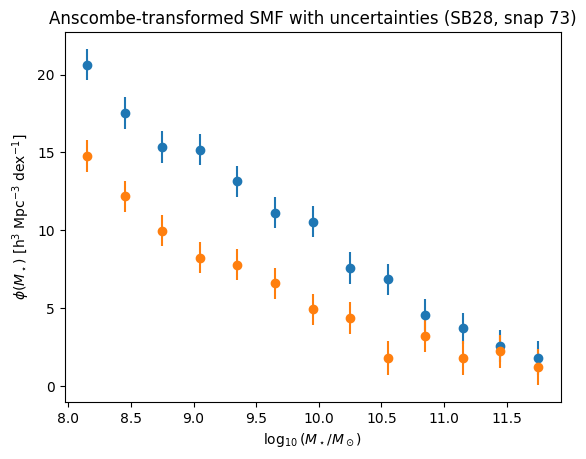

In [12]:
B = len(log10M)                         # 13
dlog = float(np.median(np.diff(log10M)))  # 0.30 for your centers

# Compute counts and uncertainties for low-fidelity data
nA, s_phiA, s_totA, s_A, s_nA = counts_uncertainty_stacked(
    phi, dlog10M=dlog, Lbox=Lbox_mpc_over_h, count_model="jeffreys", frac_floor=0.0
)
# Compute counts and uncertainties for high-fidelity data
nA_hf, s_phiA_hf, s_totA_hf, s_A_hf, s_nA_hf = counts_uncertainty_stacked(
    phi_hf, dlog10M=dlog, Lbox=Lbox_mpc_over_h, count_model="jeffreys", frac_floor=0.0
)
# Anscombe transformation
mA = anscombe(nA)  # Mean in Anscombe space
mA_hf = anscombe(nA_hf)  # Mean in Anscombe space for high-fidelity data

# Plotting Anscombe-transformed SMF with uncertainties
plt.errorbar(log10M, mA[sim_idx, :], yerr=s_A[sim_idx, :], fmt='o', label='Anscombe-transformed SMF with uncertainties')
plt.errorbar(log10M, mA_hf[sim_idx, :], yerr=s_A_hf[sim_idx, :], fmt='o', label='HF Anscombe-transformed SMF with uncertainties')
plt.xlabel(r"$\log_{10}(M_\star / M_\odot)$")
plt.ylabel(r"$\phi(M_\star)$ [h$^3$ Mpc$^{-3}$ dex$^{-1}$]")
# plt.yscale('log')
plt.title("Anscombe-transformed SMF with uncertainties (SB28, snap 73)")

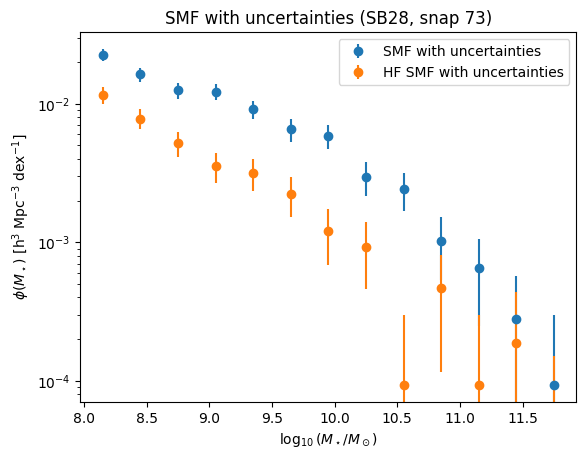

In [13]:
# Plotting the SMF with uncertainties
plt.errorbar(log10M, phi[sim_idx, :], yerr=s_tot[sim_idx, :], fmt='o', label='SMF with uncertainties')
plt.errorbar(log10M, phi_hf[sim_idx, :], yerr=s_tot_hf[sim_idx, :], fmt='o', label='HF SMF with uncertainties')
plt.xlabel(r"$\log_{10}(M_\star / M_\odot)$")
plt.ylabel(r"$\phi(M_\star)$ [h$^3$ Mpc$^{-3}$ dex$^{-1}$]")
plt.yscale('log')
plt.title("SMF with uncertainties (SB28, snap 73)")
plt.legend()

Text(0.5, 0.98, 'SMF with uncertainties (SB28, snap 73)')

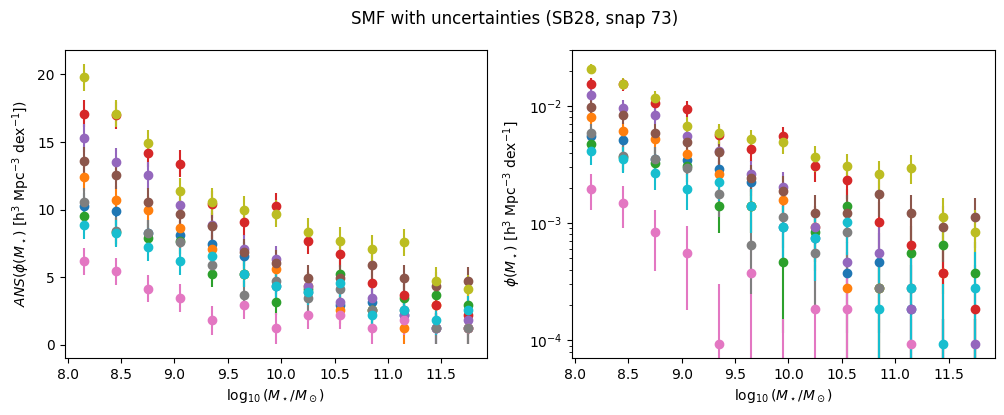

In [14]:
## Plotting multiple simulations
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for sim_idx in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    ax[0].errorbar(log10M, mA[sim_idx, :], yerr=s_A[sim_idx, :], fmt='o', )
    ax[1].errorbar(log10M, phi[sim_idx, :], yerr=s_tot[sim_idx, :], fmt='o',)

ax[0].set_xlabel(r"$\log_{10}(M_\star / M_\odot)$")
ax[0].set_ylabel(r"$ANS(\phi(M_\star)$ [h$^3$ Mpc$^{-3}$ dex$^{-1}$])")
ax[1].set_xlabel(r"$\log_{10}(M_\star / M_\odot)$")
ax[1].set_ylabel(r"$\phi(M_\star)$ [h$^3$ Mpc$^{-3}$ dex$^{-1}$]")
ax[1].set_yscale('log')

fig.suptitle("SMF with uncertainties (SB28, snap 73)")
# plt.legend()